In [11]:
path = '/home/turma02/Imagens/dc_small/'

In [12]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [13]:
modelo = ResNet50(weights = 'imagenet')

In [14]:
img = path + 'images.jpeg'

In [15]:
img  = image.load_img(img, target_size=(224, 224))

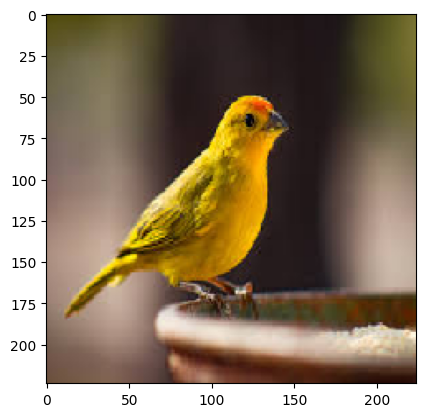

In [16]:
plt.imshow(img)

In [17]:
img_p = image.img_to_array(img)
img_p = np.expand_dims(img_p, axis = 0)
img_p = preprocess_input(img_p)

In [18]:
preds = modelo.predict(img_p)

I0000 00:00:1737142469.425101   13143 service.cc:148] XLA service 0x7d3ca8047fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1737142469.425145   13143 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2025-01-17 15:34:29.543086: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737142470.127996   13143 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-01-17 15:34:31.675217: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


I0000 00:00:1737142472.548935   13143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [19]:
print('Predições: ', decode_predictions(preds, top = 3)[0])

Predições:  [('n01531178', 'goldfinch', np.float32(0.82833606)), ('n01532829', 'house_finch', np.float32(0.10673495)), ('n01530575', 'brambling', np.float32(0.041558526))]


In [20]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [21]:
num_classes = 2

In [22]:
tf.random.set_seed(0)

In [23]:
modelo_base = ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))

In [24]:
for layer in modelo_base.layers:
    layer.trainable = False

In [25]:
modelo = tf.keras.Sequential(
    [modelo_base,
     GlobalAveragePooling2D(),
     Dense(1024, activation = 'relu'),
     Dense(num_classes, activation = 'softmax')
    ])

In [63]:
path = '/home/turma02/Imagens/dc_small/'

In [64]:
def cria_dataframe(caminho):
    arquivos = []
    rotulos = []
    for arquivo in os.listdir(caminho):
        if arquivo.startswith('cat'):  # Corrigido para acessar o nome do arquivo
            rotulos.append('cat')
        elif arquivo.startswith('dog'):  # Corrigido para acessar o nome do arquivo
            rotulos.append('dog')
        arquivos.append(arquivo)
    return pd.DataFrame({'arquivo': arquivos, 'rotulo': rotulos}) 

In [65]:
# Criando o DataFrame a partir do diretório de treinamento
df_dados = cria_dataframe(os.path.join(path, 'train'))

In [66]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   arquivo  2000 non-null   object
 1   rotulo   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [67]:
train_df, validation_df = train_test_split(df_dados, test_size = 0.2,
                                           stratify = df_dados['rotulo'], random_state = 0)

In [68]:
test_df = cria_dataframe(os.path.join(path, 'test'))

In [69]:
train_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

In [70]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory = os.path.join(path, 'train'),
    x_col = 'arquivo',
    y_col = 'rotulo',
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical'
)

Found 1600 validated image filenames belonging to 2 classes.


In [71]:
validation_generator = validation_datagen.flow_from_dataframe(
    test_df,
    directory = os.path.join(path, 'test'),
    x_col = 'arquivo',
    y_col = 'rotulo',
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical'
)

Found 1000 validated image filenames belonging to 2 classes.


In [72]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory = os.path.join(path, 'test'),
    x_col = 'arquivo',
    y_col = 'rotulo',
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical'
)

Found 1000 validated image filenames belonging to 2 classes.


In [73]:
modelo.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                                                    loss='categorical_crossentropy',
                                                    metrics=['accuracy'])

In [74]:
modelo.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // train_generator.batch_size,
    validation_data = validation_generator,
    validation_steps = validation_generator.samples // validation_generator.batch_size,
    epochs = 10
)

/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 498ms/step - accuracy: 0.9828 - loss: 0.0611 - val_accuracy: 0.9844 - val_loss: 0.0976
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - accuracy: 0.9984 - loss: 0.0059 - val_accuracy: 0.9802 - val_loss: 0.1030
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - accuracy: 1.0000 - loss: 6.6164e-04 - val_accuracy: 0.9792 - val_loss: 0.1078
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 331ms/step - accuracy: 1.0000 - loss: 9.6840e-04 - val_accuracy: 0.9823 - val_loss: 0.0998
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - accuracy: 1.0000 - loss: 1.4462e-04 - val_accuracy: 0.9823 - val_loss: 0.0954
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 1.0000 - loss: 7.1400e-05 - val_accuracy: 0.9781 - val_loss: 0.1288
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - accuracy: 1.0000 - loss: 4.5366e-05 - val_accuracy: 0.9812 - val_loss: 0.1185
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 335ms/step - accuracy: 1.0000 - loss: 1.87

In [75]:
test_loss, test_accuracy = modelo.evaluate(test_generator, steps = test_generator.samples // test_generator.batch_size)
print(f'Acuracia no Teste: {test_accuracy}')

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.9847 - loss: 0.0916
Acuracia no Teste: 0.9833333492279053


In [76]:
modelo.save('resnet_10_epoch_dogs_cats.keras')

In [77]:
def predicao_img(imagem, modelo):
    img = image.load_img(imagem, target_size = (224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    img_array = preprocess_input(img_array)
    predicoes = modelo.predict(img_array)
    classes = {0: 'cat', 1: 'dog'}
    classes_predita = classes[np.argmax(predicoes[0])]
    return classes_predita, img

In [78]:
amostra = path + 'img9.jpeg'
classe_predita, img_resposta = predicao_img(amostra, modelo)
plt.figure(figsize = (3, 3))
plt.imshow(img_resposta)
plt.title(f'Classe: {classe_predita}')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/turma02/Imagens/dc_small/img9.jpeg'